In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

In [92]:
ds = pd.read_csv('Titanic-Dataset.csv')

In [93]:
ds

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [94]:
ds.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived      1.000000
Sex           0.543351
Fare          0.257307
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.077221
Embarked_S   -0.155660
Pclass       -0.338481
Name: Survived, dtype: float64


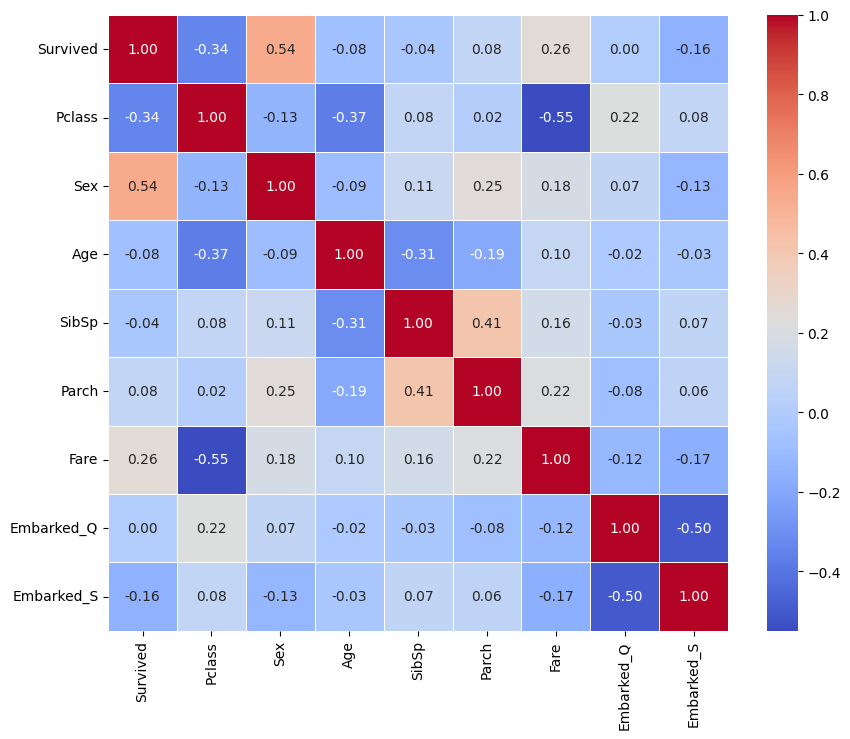

In [95]:
ds = pd.read_csv('Titanic-Dataset.csv')

ds = ds.drop(['Name', 'Cabin', 'Ticket', 'PassengerId'], axis=1)

ds['Sex'] = ds['Sex'].map({'male': 0, 'female': 1})
ds = pd.get_dummies(ds, columns=['Embarked'], drop_first=True)

corr = ds.corr()
print(corr['Survived'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

In [96]:
ds = ds.drop(['Embarked_Q', 'SibSp'], axis=1)

In [97]:
ds

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked_S
0,0,3,0,22.0,0,7.2500,True
1,1,1,1,38.0,0,71.2833,False
2,1,3,1,26.0,0,7.9250,True
3,1,1,1,35.0,0,53.1000,True
4,0,3,0,35.0,0,8.0500,True
...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,13.0000,True
887,1,1,1,19.0,0,30.0000,True
888,0,3,1,NaN,2,23.4500,True
889,1,1,0,26.0,0,30.0000,False


In [ ]:
ds = ds.rename(columns={
    'Survived': 'Survived',
    'Pclass': 'pclass',
    'Sex': 'sex',
    'Age': 'age',
    'Parch': 'parch',
    'Fare': 'fare',
    'Embarked_S': 'embarked_s'
})
ds

,Survived,pclass,sex,age,parch,fare,embarked_s
0,0,3,0,22.0,0,7.2500,True
1,1,1,1,38.0,0,71.2833,False
2,1,3,1,26.0,0,7.9250,True
3,1,1,1,35.0,0,53.1000,True
4,0,3,0,35.0,0,8.0500,True
...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,13.0000,True
887,1,1,1,19.0,0,30.0000,True
888,0,3,1,NaN,2,23.4500,True
889,1,1,0,26.0,0,30.0000,False


In [100]:
ds.isnull().sum()

Survived        0
pclass          0
sex             0
age           177
parch           0
fare            0
embarked_s      0
dtype: int64

In [101]:
ds.shape
ds = ds.dropna()
ds = ds.drop_duplicates()

In [102]:
X = ds.drop('Survived', axis=1)
y = ds['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(537, 6)
(135, 6)


In [103]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

coef = pd.DataFrame({'feature': X.columns, 'coef': model.coef_[0]})
print(coef.sort_values(by='coef', ascending=False))

      feature      coef
1         sex  1.165672
4        fare  0.073935
3       parch -0.122130
5  embarked_s -0.128127
2         age -0.632795
0      pclass -1.037780


Accuracy: 0.7703703703703704
Precision: 0.6451612903225806
Recall: 0.8163265306122449
F1 Score: 0.7207207207207207
ROC-AUC: 0.8304461319411485

               precision    recall  f1-score   support

           0       0.88      0.74      0.81        86
           1       0.65      0.82      0.72        49

    accuracy                           0.77       135
   macro avg       0.76      0.78      0.76       135
weighted avg       0.79      0.77      0.77       135



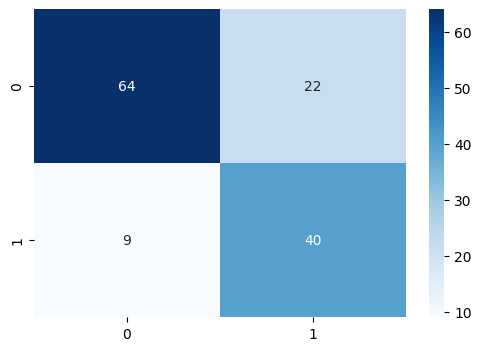

In [105]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

In [108]:
params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "solver": ["liblinear"],
}

grid = GridSearchCV(
    LogisticRegression(random_state=42), params, cv=5, scoring="accuracy"
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

best_model = grid.best_estimator_
pred2 = best_model.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, pred2))

Best params: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
Best score: 0.7859120803046036
Test accuracy: 0.7703703703703704


In [110]:
with open('titanic_logistic_model.pkl', 'wb') as file:
  pickle.dump(best_model, file)

In [111]:
with open('scaler.pkl', 'wb') as file:
  pickle.dump(scaler, file)

In [129]:
with open('titanic_logistic_model.pkl', 'rb') as file:
  loaded_model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
  loaded_scaler = pickle.load(file)

new_passenger = [[3, 0, 33, 2, 50, 1]]
new_passenger_scaled = loaded_scaler.transform(new_passenger)

prediction = loaded_model.predict(new_passenger_scaled)
probability = loaded_model.predict_proba(new_passenger_scaled)

print('Predicted Survived (0 = No, 1 = Yes):', prediction[0])
print('Prediction Probability:', probability[0])

Predicted Survived (0 = No, 1 = Yes): 0
Prediction Probability: [0.92872951 0.07127049]


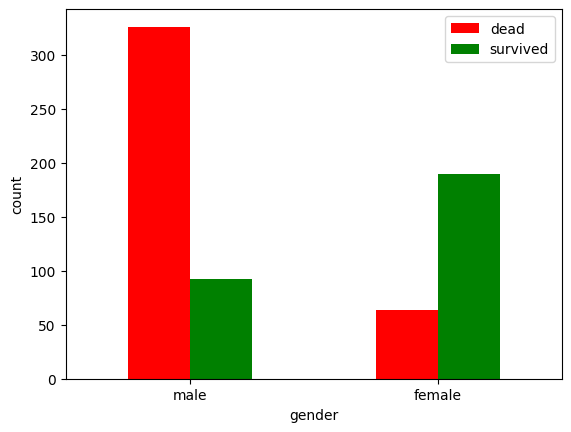

In [131]:
survival_counts = pd.crosstab(ds['sex'], ds['Survived'])
survival_counts.plot(kind='bar', color=['red', 'green'])

plt.xlabel('gender')
plt.ylabel('count')
plt.legend(['dead', 'survived'])
plt.xticks([0, 1], ['male', 'female'], rotation=0)
plt.show()